## Безусловная генерация рентгеновских снимков

### Просмротр датасета

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.io import read_image
from torch.nn import functional as F 

from pathlib import Path
from torch.optim import AdamW
from torch.amp import GradScaler, autocast

import kagglehub
import os

In [2]:
def download(variant=None):
    """
        p - dataset with pneumonia, path point to chest_xray where have test and train folders.
            in train 2 folders: NORMAL and PNEUMONIA (into on of folders .jpeg pictures)
        c - dataset with covid
        v - dataset with big variance of labels
    """
    path = ''
    if variant == 'p':
        path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
        print("Path to dataset files:", path)
        return path

    if variant == 'c':
        path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
        print("Path to dataset files:", path)
        return path
    
    if variant == 'v':
        path = kagglehub.dataset_download("mathurinache/chestxdetdataset")
        print("Path to dataset files:", path)
        return path

    print('huh?')

In [3]:
path = download('p')

Path to dataset files: C:\Users\panika\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [34]:
path2 = download('c')

Path to dataset files: C:\Users\panika\.cache\kagglehub\datasets\tawsifurrahman\covid19-radiography-database\versions\5


In [5]:
def analyze(path, v):
    if v == 'p':
        normal_path = path + '\\chest_xray\\train\\NORMAL'
        pneumonia_path = path + '\\chest_xray\\train\\PNEUMONIA'
        normal = os.listdir(normal_path)
        print(f'В файле количество нормальных здоровых: {len(normal)}')

        sick = os.listdir(pneumonia_path)
        print(f'В файле количество больных рентгенов: {len(sick)}')

        H = np.array([])
        W = np.array([])
        for sc in sick:
            img = read_image(pneumonia_path + '\\' + sc)
            H = np.append(H, img.shape[1])
            W = np.append(W, img.shape[2])

        fig, axs = plt.subplots(1, 2)
        axs[0].hist(H, color='blue', edgecolor='black')
        axs[0].set_title('Гистограмма по H (количество строк)')
        axs[0].grid()
        axs[1].hist(W, color='blue', edgecolor='black')
        axs[1].set_title('Гистрограмма по W (количество столбцов)')
        axs[1].grid()

        plt.tight_layout()
        plt.show()

В файле количество нормальных здоровых: 1341
В файле количество больных рентгенов: 3875


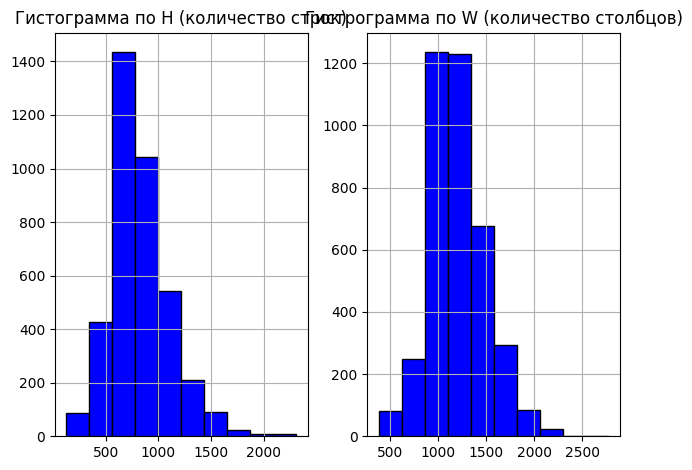

In [6]:
analyze(path, 'p')

Проболема большая - рентгены разного рзамера. Если сжимать их, например, до 256 на 256 может получиться не красивые мыльные изображения для обучающего набора, что является проблемой. Ладно попробуем 256 на 256 потом видно будет

In [7]:
def import_pirctures(path, v):
    if v == 'p':
        path = path + '\\chest_xray\\train'

        transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

        dataset = datasets.ImageFolder(root=path, transform=transform)
        print(len(dataset))
        plt.imshow(dataset[0][0][0], cmap='grey')
        plt.xticks([])
        plt.yticks([])
        return dataset
    
    print('huh?')

5216


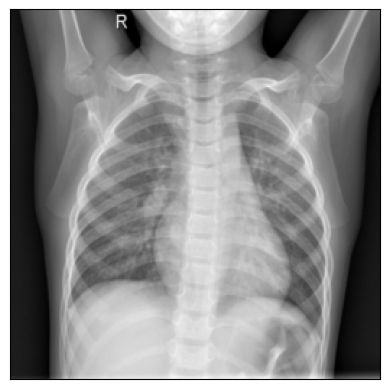

In [8]:
dataset = import_pirctures(path, 'p')

In [ ]:
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

При предварительном просмотре рентгеновских снимков 256 на 256 оказались не такими плохими так, что пробуем дальше

### Написание архитектуры модели

In [10]:
class AttentionBlock(nn.Module):
    def __init__(self, channels, n_heads=1):
        super().__init__()
        self.channels = channels
        self.norm = nn.GroupNorm(32, channels)
        self.inner_dim = channels // 4

        self.q = nn.Conv2d(channels, self.inner_dim, kernel_size=1, bias=False)
        self.k = nn.Conv2d(channels, self.inner_dim, kernel_size=1, bias=False)
        self.v = nn.Conv2d(channels, channels, kernel_size=1, bias=False)

        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1, bias=False)
        self.scale = self.inner_dim ** (-0.5)

    def forward(self, x):
        b, c, h, w = x.shape
        n = h * w
        h_ = self.norm(x)
        
        q = self.q(h_).view(b, self.inner_dim, n)
        k = self.k(h_).view(b, self.inner_dim, n)
        v = self.v(h_).view(b, c, n)

        attn = torch.einsum('b d i, b d j -> b i j', q, k)
        attn = torch.softmax(self.scale * attn, dim=-1)

        out = torch.einsum('b i j, b c j -> b c i', attn, v)

        out = out.view(b, c, h, w)
        return x + self.proj_out(out)

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, groups=32):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.time_mlp = nn.Linear(time_dim, out_channels)

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.activation = F.silu

    def forward(self, x, time_embedding):
        h = self.norm1(x)
        h = self.activation(h)
        h = self.conv1(h)
                                  
        bias = self.time_mlp(self.activation(time_embedding))
        h = h + bias[:, :, None, None]

        h = self.norm2(h)
        h = self.activation(h)
        h = self.conv2(h)

        return h + self.shortcut(x)

In [12]:
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_dim)
        self.down = nn.Conv2d(out_channels, out_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x, time_embedding):
        x = self.res(x, time_embedding)
        return x, self.down(x)

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_dim)
        self.conv = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x, skip, time_embedding):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.cat([x, skip], dim=1)
        x = self.res(x, time_embedding)
        return self.conv(x)

In [13]:
class Unet256(nn.Module):
    def __init__(self, in_channels=1, time_dim=256):
        super().__init__()
        self.time_dim = time_dim
        
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.init_conv = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)

        self.downs = nn.ModuleList([
            DownBlock(64, 128, time_dim),
            DownBlock(128, 256, time_dim),
            DownBlock(256, 512, time_dim),
            DownBlock(512, 512, time_dim),
            DownBlock(512, 512, time_dim)
        ])

        self.bottleneck = nn.ModuleList([
            ResidualBlock(512, 512, time_dim),
            AttentionBlock(512),
            ResidualBlock(512, 512, time_dim)
        ])

        self.ups = nn.ModuleList([
            UpBlock(1024, 512, time_dim),
            UpBlock(1024, 512, time_dim),
            UpBlock(1024, 256, time_dim),
            UpBlock(512, 128, time_dim),
            UpBlock(256, 64, time_dim)
        ])

        self.final_conv = nn.Conv2d(64, in_channels, kernel_size=1)

    def forward(self, x, time):
        time = time_embedding(time, self.time_dim)
        time = self.time_mlp(time)

        x = self.init_conv(x)

        skips = []
        for down in self.downs:
            skip, x = down(x, time)
            skips.append(skip)

        for block in self.bottleneck:
            if isinstance(block, ResidualBlock):
                x = block(x, time)
            else:
                x = block(x) 

        for up in self.ups:
            skip = skips.pop()
            x = up(x, skip, time)
            
        return self.final_conv(x)

### Зашумление изображений

Ранее $\overline\alpha$ задавалось образом:

1) Вычисляется $\beta_t$ линейно от какого то начала до конца. $\beta_t$ постепенно увеличивалось, то есть к конечному шагу сильнее зашумляя картинку.
2) А $\alpha_t$ всего лишь линейное преобразование $1 - \beta_t$
3) $\overline\alpha_t = \prod_{i=0}^{t} \alpha_t$

Таким образом $\overline\alpha_t = f(t)$, где $f(t) = \prod_{i=0}^{t} (1 - \beta_t) = \prod_{i=0}^{t} (1 - (\beta_0 + \frac{1}{T}\cdot t))$ - убывает с экспоненциональной скоростью

Gemeni предлагает сделать
$\overline\alpha_t = \dfrac{f(t)}{f(0)}$, где $f(t) = cos^2(\dfrac{t/T + s}{1 + s} \cdot \dfrac{\pi}{2})$

Интуитивно вообще не ясно как это работает, надо протестировать и вообще осознать в чем смысл

In [14]:
def f(t, timesteps):
    s = 0.008
    return torch.cos(((t / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2

def draw_c():
    timesteps = 1000
    steps = timesteps + 1
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(beta_start, beta_end, steps)
    alphas = 1 - betas
    alphas_cumprod_1 = torch.cumprod(alphas, axis=0)
    
    t = torch.linspace(0, timesteps, steps)
    alphas_cumprod = f(t, timesteps)
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]

    plt.scatter(t, alphas_cumprod, color='blue', label='Косинусное зашумление')
    plt.scatter(t, alphas_cumprod_1, color='red', label='Обычное зашумление')
    plt.title(r'Значение $\overline{\alpha_t}$')
    plt.legend()
    plt.grid()

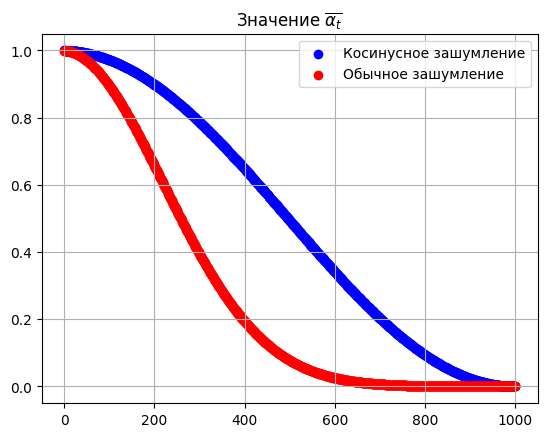

In [15]:
draw_c()

### Вывод

Да, походу gemeni жестко прав, потому что косинусно убывает не так агрессивно и ближе к линейному. Это дает, наверно, $x_0$ умножается на слишком маленькое изображение и шум становится преобладать

### Начальные параметры и фукнции зашумления и эмбединга

In [16]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((t / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 0.0001, 0.9999)

In [17]:
def q_sample(x_start, t, alphas_cumprod, noise):  
    """
    Add noise to x_start
    Args:
        x_start: [Batch, canals, W, H]
        t: [B,]
        alphas_cumprod: array of alphas [N]
        noise: [Batch, canals, W, H] ~ N(0, I)
    """
    sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1 - alphas_cumprod[t]).view(-1, 1, 1, 1)

    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

def time_embedding(t, dim):
    """
    n = dim
    t -> {sin(w1*t), cos(w1*t), ... sin(wn*t), cos(wn*t)}
    Args:
        t: [B, ]
        dim: scalar
    """
    idx = torch.arange(0, dim // 2, device=t.device)
    w = 1 / (10000 ** ((2 * idx) / dim))
    angles = t[:, None] * w[None, :]
    sin = torch.sin(angles)
    cos = torch.cos(angles)
    return torch.cat([sin, cos], dim=-1)

### Функция ошибки

На больших t (сильный шум) предсказать $\varepsilon$ легко — это почти само изображение $x_t$. На малых t (слабый шум) предсказать $varepsilon$ крайне сложно, так как это тончайшие текстуры. Обычный MSE одинаково штрафует за ошибки на всех уровнях t. Из-за этого на малых t loss маленький по определению, что дает модели плохо реагировать на маленьких t, но хорошо при больших. Для этого есть предлложение взять веса для каждого:

$w_t = min(SNR(t), 5)$, где $SNR(t) = \dfrac{\overline\alpha_t}{1-\overline\alpha_t}$

In [18]:
def draw_w():
    timesteps = 1000
    betas = cosine_beta_schedule(timesteps)
    alphas = 1 - betas
    alphas_cumprod = torch.cumprod(alphas, axis=0)
    alphas_cumprod.to('cpu')
    timesteps = 1000
    t = torch.linspace(0, timesteps, timesteps)
    w = torch.min(alphas_cumprod / (1 - alphas_cumprod), 5 * torch.ones_like(alphas_cumprod))
    plt.scatter(t, w, color='blue')
    plt.grid()

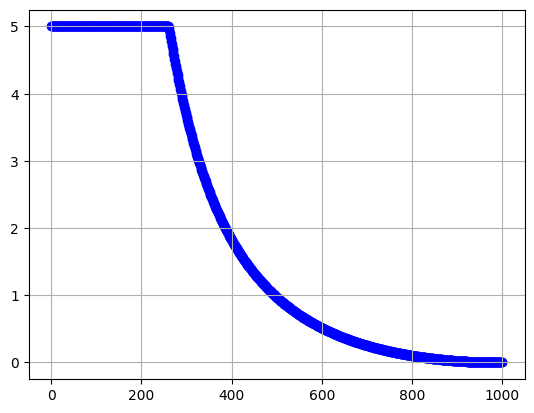

In [19]:
draw_w()

### Обучение модели

In [25]:
def train_epoch(model, dataloader, optimizer, scaler, alphas_cumprod, device):
    model.train()
    total_loss = 0
    timesteps = len(alphas_cumprod)

    for batch_idx, (x0, _) in enumerate(dataloader):
        x0 = x0.to(device)
        batch_size = x0.shape[0]

        # 1. Сэмплируем случайные моменты времени t для каждой картинки в батче
        t = torch.randint(0, timesteps, (batch_size,), device=device).long()

        # 2. Forward Process: Добавляем шум согласно Reparameterization Trick
        # x_t = sqrt(alpha_bar) * x0 + sqrt(1 - alpha_bar) * eps
        noise = torch.randn_like(x0)
        
        sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1 - alphas_cumprod[t]).view(-1, 1, 1, 1)
        
        xt = sqrt_alphas_cumprod_t * x0 + sqrt_one_minus_alphas_cumprod_t * noise

        # 3. Предсказание шума с использованием Mixed Precision
        with autocast('cuda'):
            predicted_noise = model(xt, t)
            
            # 4. Расчет Min-SNR-5 Weighting
            # Статья: Hang et al. (2023). Формула: weight = min(SNR, 5)
            snr = alphas_cumprod[t] / (1 - alphas_cumprod[t])
            mse_loss_weights = torch.clamp(snr, max=5.0)
            
            # Считаем MSE без усреднения (reduction='none')
            loss_map = F.mse_loss(predicted_noise, noise, reduction='none')
            # Усредняем по пространству [C, H, W]
            loss_per_sample = loss_map.mean(dim=[1, 2, 3])
            # Применяем веса Min-SNR и усредняем по батчу
            loss = (loss_per_sample * mse_loss_weights).mean()

        # 5. Обратное распространение ошибки
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        
        # Unscale для градиентного клиппинга
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        
    return total_loss / len(dataloader)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Unet256().to(device)

# 3. Настройка оптимизатора (SOTA для трансформеров и диффузии)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
# 4. Инициализация Scaler для Mixed Precision (FP16)
scaler = GradScaler('cuda')

timesteps = 1000
betas = cosine_beta_schedule(timesteps)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, axis=0).to(device)

epochs = 100

print(f'start to train {epochs} epochs')
for epoch in range(epochs):
    avg_loss = train_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        scaler=scaler,
        alphas_cumprod=alphas_cumprod,
        device=device
    )
    
    print(f"Epoch {epoch} | Loss: {avg_loss:.6f}")
    
    if epoch % 10 == 0:
        torch.save(model.state_dict(), f"unet256_xray_epoch_{epoch}.pth")

start to train 100 epochs
Epoch 0 | Loss: 0.112668
Epoch 1 | Loss: 0.205714
Epoch 2 | Loss: 0.086223
Epoch 3 | Loss: 0.074906
Epoch 4 | Loss: 0.080362


KeyboardInterrupt: 

### Заметки по датасетам

- covid19-radiography-database - датасет с ковидом и черными хуевыми масками
- https://www.kaggle.com/competitions/siim-acr-pneumothorax-segmentation/data - рентген + рисунке вроде притом нормальные рисунки, но есть пользовательское соглашение какое то странное и подтвеждение лица
- https://github.com/Deepwise-AILab/ChestX-Det-Dataset - нихуя не понял
- https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data - Нормальная и пневмония без схем
- https://github.com/ieee8023/covid-chestxray-dataset - какая-та хуйня с метоинформацией, но схем нет


Wasserthal et al., "TotalSegmentator: Robust Segmentation of 117 Anatomical Structures" (2023). - какая та интересная статья


### Информация

Saharia et al., "Palette: Image-to-Image Diffusion Models" (2022) - статья по получению изображения из изображения

https://arxiv.org/pdf/1901.00542 - хуйня просто GAN

Статья: Rippel et al., "Spectral Representations for Convolutional Neural Networks" (2015). Доказывает превосходство обучаемых сверток для сохранения спектральных характеристик при уменьшении разрешения.

Статья для контроля: Vaswani et al., "Attention Is All You Need" (2017). В разделе 3.2.2 (Multi-Head Attention) указано, что $d_k = d_v = d_{model} / h$. То есть размерность проекций действительно меньше исходной размерности модели.

Статья для контроля: Vaswani et al., "Attention Is All You Need" (2017). Смотри раздел 3.2.2 (Multi-Head Attention), формула (2). Там явно указана матрица $W_0$, которая перемножается с результатом внимания. Без этой матрицы механизм Multi-head (и Single-head) математически не полон.

Математика: Каждый новый вектор пикселя $x_i$ становится линейной комбинацией векторов 

$x_i = \displaystyle\sum_{j=1}^{N}\alpha_{ij}v_j$
 
Проблема: Эта операция перемешивает информацию между пикселями, но она не меняет «смысл» самих признаков внутри вектора. Если в векторе $v$ на 10-й позиции был признак «край легкого», то после суммирования на 10-й позиции останется усредненный признак «край легкого».

SiLU (Swish) Активация
Математика: f(x)=x⋅σ(x).
Зачем: В диффузии мы аппроксимируем сложную поверхность градиента ∇logp(x). SiLU — гладкая и немонотонная функция. В отличие от ReLU (у которой производная в нуле разрывна), SiLU обеспечивает стабильность градиентов при 1000 итерациях обратного процесса.
Статья: Elfwing et al. (2017).

Статья: He et al., "Identity Mappings in Deep Residual Networks" (2016). Авторы доказали, что активация перед операцией делает ландшафт потерь более гладким.

Статья: Ho et al., "Denoising Diffusion Probabilistic Models" (2020). См. раздел 3.2: «The time step t  is specified to the network by adding a Transformer-style positional embedding... into every residual block using a 2-layer MLP».


Статья: Nichol & Dhariwal, "Improved Denoising Diffusion Probabilistic Models" (2021). См. Section 4, Figure 4. - Косинусное зашумление

Статья: Hang et al., "Efficient Diffusion Training via Min-SNR Weighting Strategy" (2023) - веса для лоса

Статья: Saharia et al., "Palette: Image-to-Image Diffusion Models" (2022). В разделе Section 4.1 авторы прямо показывают, что при малом количестве данных (задачи раскрашивания или восстановления) условная диффузия сходится там, где безусловная выдает шум.

# Я в очке

Смешные галлюционации Gemeni

3. SOTA-решение: Каскадная Диффузия (Cascaded Diffusion)
Чтобы не выбирать между «мылом» и «анатомическим хаосом», в профессиональной медицине используют каскады.
Статья: Ho et al., "Cascaded Diffusion Models for High Fidelity Image Generation" (2022).
Архитектурное решение:
Low-Res Model (
64
×
64
64×64
 или 
128
×
128
128×128
): Обучается по твоей «Схеме». Её задача — выстроить анатомию (скелет, положение органов). Тут «мыло» допустимо.
Super-Resolution Model (SR): Вторая диффузионная модель. Она принимает на вход результат первой модели (апскейл до 
512
512
 или 
1024
1024
) и оригинальную схему. Её задача — навести резкость и текстуру, используя схему как направляющую.
Статья по SR: Saharia et al., "Image Super-Resolution via Iterative Refinement" (2022) (модель SR3).

In [ ]:
"cuda" if torch.cuda.is_available() else "cpu"